In [1]:
# Figure 3 4 A B C plot TrkB TrkC heatmaps
### select units based on zeta test results


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pickle
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import statistics
%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42 # enables editing of strings of characters rather than individual characters
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [ ]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [4]:
laser_samp_dir = os.path.join(data_dir, 'sync_samp')
recording_groups = ['TrkC','TrkB','TrkC_S1HP','TrkB_S1HP']

In [5]:
# load the laser time for each set 0 (saved again 25/12/10)

fs_laser = 30000
laser_samp_sync_sets = {}
laser_samp_async_sets = {}

for iset in range(1): # only load set 0

    sync_samp_file = 'sync_samp_set'+str(iset)+'.npy'
    async_samp_file = 'async_samp_set'+str(iset)+'.npy'

    laser_samp_sync_file = os.path.join(laser_samp_dir, sync_samp_file)
    laser_samp_async_file = os.path.join(laser_samp_dir, async_samp_file)

    laser_samp_sync = np.load(laser_samp_sync_file)
    laser_samp_async = np.load(laser_samp_async_file)

    laser_samp_sync_sets[iset] = laser_samp_sync
    laser_samp_async_sets[iset] = laser_samp_async


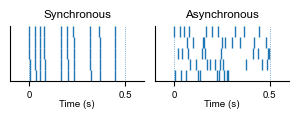

In [6]:
# plot Fig 3A laser traces for sync async
sync_set = 0

laser_samp_sync = laser_samp_sync_sets[sync_set]  # load the laser_samp for the file
laser_samp_async = laser_samp_async_sets[sync_set]

fig, ax = plt.subplots(1,2, figsize= [3,1.2])
yplot = 0

for itrace in range(5): # 5 traces
    
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+1,color='#1f77b4', linewidth=1)
    ax[1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+1,color='#1f77b4', linewidth=1)
    yplot += 1

for iax in [0,1]:   
    ax[iax].set_xlim(-0.1,0.6)
    ax[iax].set_ylim(0,5)
    ax[iax].invert_yaxis()
    ax[iax].set_xlabel('Time (s)',labelpad=0)
    ax[iax].axvline(0, linestyle = ':', linewidth=0.5)
    ax[iax].axvline(0.5, linestyle = ':', linewidth=0.5)
    ax[iax].set_xticks(ticks=[0,0.5], labels=[0,0.5], rotation = 0)
    ax[iax].spines['top'].set_visible(False)
    ax[iax].spines['right'].set_visible(False)
    ax[iax].spines['left'].set_bounds((0, 5))
    ax[iax].get_yaxis().set_visible(False)
ax[0].set_title('Synchronous')
ax[1].set_title('Asynchronous')
plt.tight_layout()
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures\laser_pattern_sync.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

In [7]:
# load data
units_select_groups = {}
nunits_cum_sum_recording_groups = {}
units_sort_by_recordingID_depth_groups = {}
allunits_zfr_groups = {}

for igroup in recording_groups:
    units_select_file_igroup = os.path.join(data_dir, 'units_select_'+igroup+'.npy')
    nunits_cum_sum_recording_file_igroup =os.path.join(data_dir, 'nunits_cum_sum_recording_'+igroup+'.npy')
    units_sort_by_recordingID_depth_file_igroup = os.path.join(data_dir,'units_sort_by_recordingID_depth_'+igroup+'.npy')
    allunits_laser1_zfr_bypads_file_igroup = os.path.join(data_dir, 'allunits_laser1_meanzarray_bypads_'+igroup+'.npy')

    units_select_groups[igroup] = np.load(units_select_file_igroup)
    nunits_cum_sum_recording_groups[igroup] = np.load(nunits_cum_sum_recording_file_igroup)
    units_sort_by_recordingID_depth_groups[igroup] = np.load(units_sort_by_recordingID_depth_file_igroup)
    allunits_zfr_groups[igroup] = np.load(allunits_laser1_zfr_bypads_file_igroup)


In [8]:
# load example unit raster dict
example_raster_file_TrkC = os.path.join(data_dir,'units_raster_example_TrkC.pickle')
example_raster_file_TrkB = os.path.join(data_dir,'units_raster_example_TrkB.pickle')
example_raster_file_TrkC_S1HP = os.path.join(data_dir,'units_raster_example_TrkC_S1HP_2.pickle')
example_raster_file_TrkB_S1HP = os.path.join(data_dir,'units_raster_example_TrkB_S1HP_2.pickle')

unit_dict_examples = {}
with open(example_raster_file_TrkC, 'rb') as handle:
    unit_dict_examples['TrkC'] = pickle.load(handle)
with open(example_raster_file_TrkB, 'rb') as handle:
    unit_dict_examples['TrkB'] = pickle.load(handle)
with open(example_raster_file_TrkC_S1HP, 'rb') as handle:
    unit_dict_examples['TrkC_S1HP'] = pickle.load(handle)
with open(example_raster_file_TrkB_S1HP, 'rb') as handle:
    unit_dict_examples['TrkB_S1HP'] = pickle.load(handle)

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_27660\1496709808.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


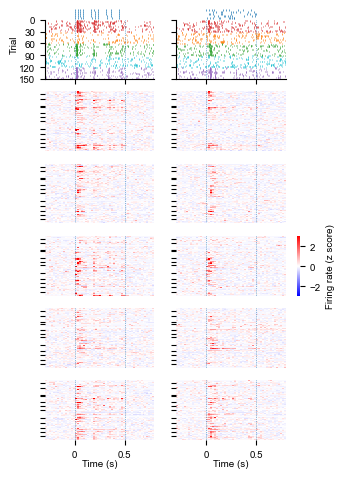

In [ ]:
# plot heatmap for all pads - TrkC forepaw - sync vs async - order 1-5 - add stim patterns and raster example
igroup = 'TrkC'
f, ax = plt.subplots(6,2,figsize=[3.3,4.8],gridspec_kw={'height_ratios':[7,6,6,6,6,6]})

color_palette = sns.color_palette("tab10")
colors = ["#d62728", "#ff7f0e","#2ca02c","#17becf","#9467bd"]

for i in range(10):
  units_select_zfr_pads = allunits_zfr_groups[igroup][units_select_groups[igroup],i,:]
  
  sns.heatmap(units_select_zfr_pads[units_sort_by_recordingID_depth_groups[igroup]],ax=ax[i%5+1,i//5], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')

  ax[i%5+1,i//5].vlines(50, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].vlines(75, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].set_xlim(35,90)

  ax[i%5+1,i//5].set_xticks([])
  ax[i%5+1,i//5].set_xlabel('')
  ax[i%5+1,i//5].set_ylabel('')

for i in [4,9]:
  ax[i%5+1,i//5].set_xlabel('Time (s)', labelpad=0)
  ax[i%5+1,i//5].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

for i in range(10):
  ax[i%5+1,i//5].set_yticks(ticks=nunits_cum_sum_recording_groups[igroup][:-1])
  # ax[4-i%5,i//5].hlines(nunits_cum_sum[:-1], 0, 100, linestyles= ':', linewidth = 0.5)

### plot example unit raster
iunit_dict = unit_dict_examples[igroup]
psth_laser1 = iunit_dict['psth_laser1']
trial_order_laser1 = iunit_dict['trial_order_laser1']
spk_time_laser1 = iunit_dict['spk_time_laser1']

y1 = 0
y2 = 0
yplot = -27 # sync traces
yplot0 = yplot
for icond in range(5): # plot sync 0-4
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
      
        ax[0,0].vlines(itrial_spktime-1, ymin=y1, ymax=y1+3,linewidth=0.5,color=colors[icond])
        y1 += 1
for icond in range(5,10): # plot async 05-9
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
        ax[0,1].vlines(itrial_spktime-1, ymin=y2, ymax=y2+3,linewidth=0.5,color=colors[icond-5])
        y2 += 1

### plot laser traces on top

for itrace in range(5): # 5 traces
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0,0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    ax[0,1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    yplot += 5

ntrials = 150
for i in [0,1]:
    ax[0,i].vlines(0, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].vlines(0.5, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].set_xlim(-0.3,0.8)
    ax[0,i].set_ylim(yplot0,150)
    ax[0,i].spines['top'].set_visible(False)
    ax[0,i].spines['right'].set_visible(False)
    ax[0,i].spines['bottom'].set_zorder(0)
    ax[0,i].spines['left'].set_bounds((0, 150))
    ax[0,i].set_xticks([0,0.5])
    ax[0,i].set_xticklabels([])
    ax[0,i].set_yticks([0,30,60,90,120,150])
    ax[0,i].invert_yaxis()

ax[0,0].set_yticklabels([0,30,60,90,120,150])
ax[0,1].set_yticklabels([])
ax[0,0].set_ylabel('Trial', labelpad=0)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.9, 0.38, 0.01, 0.125]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(hspace=0.2, wspace=0.2) 
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\heatmap_raster_TrkC_5pads_zeta_order15_4.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_27660\385588211.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


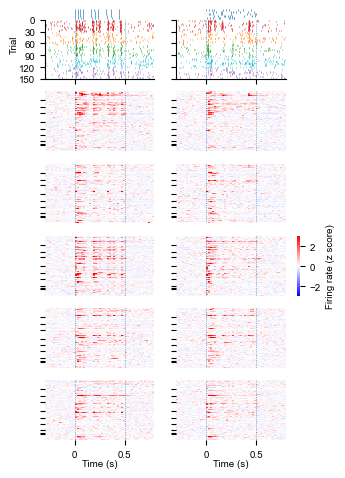

In [ ]:
# plot heatmap for all pads - TrkB forepaw - sync vs async - order 1-5 - add stim patterns and raster example
igroup = 'TrkB'
f, ax = plt.subplots(6,2,figsize=[3.3,4.8],gridspec_kw={'height_ratios':[7,6,6,6,6,6]})

color_palette = sns.color_palette("tab10")
colors = ["#d62728", "#ff7f0e","#2ca02c","#17becf","#9467bd"]

for i in range(10):
  units_select_zfr_pads = allunits_zfr_groups[igroup][units_select_groups[igroup],i,:]
  
  sns.heatmap(units_select_zfr_pads[units_sort_by_recordingID_depth_groups[igroup]],ax=ax[i%5+1,i//5], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')

  ax[i%5+1,i//5].vlines(50, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].vlines(75, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].set_xlim(35,90)

  ax[i%5+1,i//5].set_xticks([])
  ax[i%5+1,i//5].set_xlabel('')
  ax[i%5+1,i//5].set_ylabel('')

for i in [4,9]:
  ax[i%5+1,i//5].set_xlabel('Time (s)', labelpad=0)
  ax[i%5+1,i//5].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

for i in range(10):
  ax[i%5+1,i//5].set_yticks(ticks=nunits_cum_sum_recording_groups[igroup][:-1])

### plot example unit raster
iunit_dict = unit_dict_examples[igroup]
psth_laser1 = iunit_dict['psth_laser1']
trial_order_laser1 = iunit_dict['trial_order_laser1']
spk_time_laser1 = iunit_dict['spk_time_laser1']

y1 = 0
y2 = 0
yplot = -27 # sync traces
yplot0 = yplot
for icond in range(5): # plot sync 0-4
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
      
        ax[0,0].vlines(itrial_spktime-1, ymin=y1, ymax=y1+3,linewidth=0.5,color=colors[icond])
        y1 += 1
for icond in range(5,10): # plot async 05-9
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
        ax[0,1].vlines(itrial_spktime-1, ymin=y2, ymax=y2+3,linewidth=0.5,color=colors[icond-5])
        y2 += 1

### plot laser traces on top

for itrace in range(5): # 5 traces
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0,0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    ax[0,1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    yplot += 5

ntrials = 150
for i in [0,1]:
    ax[0,i].vlines(0, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].vlines(0.5, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].set_xlim(-0.3,0.8)
    ax[0,i].set_ylim(yplot0,150)
    ax[0,i].spines['top'].set_visible(False)
    ax[0,i].spines['right'].set_visible(False)
    ax[0,i].spines['bottom'].set_zorder(0)
    ax[0,i].spines['left'].set_bounds((0, 150))
    ax[0,i].set_xticks([0,0.5])
    ax[0,i].set_xticklabels([])
    ax[0,i].set_yticks([0,30,60,90,120,150])
    ax[0,i].invert_yaxis()

ax[0,0].set_yticklabels([0,30,60,90,120,150])
ax[0,1].set_yticklabels([])
ax[0,0].set_ylabel('Trial', labelpad=0)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.9, 0.38, 0.01, 0.125]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(hspace=0.2, wspace=0.2) 
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\heatmap_raster_TrkB_5pads_zeta_order15_4.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_27660\948932471.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


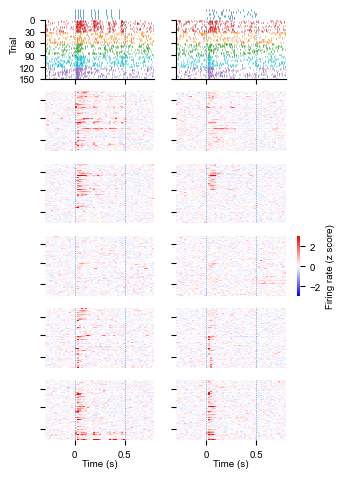

In [ ]:
# plot heatmap for all pads - TrkC hindpaw - sync vs async - order 1-5 - add stim patterns and raster example
igroup = 'TrkC_S1HP'
f, ax = plt.subplots(6,2,figsize=[3.3,4.8],gridspec_kw={'height_ratios':[7,6,6,6,6,6]})

color_palette = sns.color_palette("tab10")
colors = ["#d62728", "#ff7f0e","#2ca02c","#17becf","#9467bd"]

for i in range(10):
  units_select_zfr_pads = allunits_zfr_groups[igroup][units_select_groups[igroup],i,:]
  
  sns.heatmap(units_select_zfr_pads[units_sort_by_recordingID_depth_groups[igroup]],ax=ax[i%5+1,i//5], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')

  ax[i%5+1,i//5].vlines(50, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].vlines(75, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].set_xlim(35,90)

  ax[i%5+1,i//5].set_xticks([])
  ax[i%5+1,i//5].set_xlabel('')
  ax[i%5+1,i//5].set_ylabel('')

for i in [4,9]:
  ax[i%5+1,i//5].set_xlabel('Time (s)', labelpad=0)
  ax[i%5+1,i//5].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

for i in range(10):
  ax[i%5+1,i//5].set_yticks(ticks=nunits_cum_sum_recording_groups[igroup][:-1])

### plot example unit raster
iunit_dict = unit_dict_examples[igroup]
psth_laser1 = iunit_dict['psth_laser1']
trial_order_laser1 = iunit_dict['trial_order_laser1']
spk_time_laser1 = iunit_dict['spk_time_laser1']

y1 = 0
y2 = 0
yplot = -27 # sync traces
yplot0 = yplot
for icond in range(5): # plot sync 0-4
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
      
        ax[0,0].vlines(itrial_spktime-1, ymin=y1, ymax=y1+3,linewidth=0.5,color=colors[icond])
        y1 += 1
for icond in range(5,10): # plot async 5-9
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
        ax[0,1].vlines(itrial_spktime-1, ymin=y2, ymax=y2+3,linewidth=0.5,color=colors[icond-5])
        y2 += 1

### plot laser traces on top

for itrace in range(5): # 5 traces
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0,0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    ax[0,1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    yplot += 5

ntrials = 150
for i in [0,1]:
    ax[0,i].vlines(0, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].vlines(0.5, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].set_xlim(-0.3,0.8)
    ax[0,i].set_ylim(yplot0,150)
    ax[0,i].spines['top'].set_visible(False)
    ax[0,i].spines['right'].set_visible(False)
    ax[0,i].spines['bottom'].set_zorder(0)
    ax[0,i].spines['left'].set_bounds((0, 150))
    ax[0,i].set_xticks([0,0.5])
    ax[0,i].set_xticklabels([])
    ax[0,i].set_yticks([0,30,60,90,120,150])
    ax[0,i].invert_yaxis()

ax[0,0].set_yticklabels([0,30,60,90,120,150])
ax[0,1].set_yticklabels([])
ax[0,0].set_ylabel('Trial', labelpad=0)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.9, 0.38, 0.01, 0.125]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(hspace=0.2, wspace=0.2) 
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\heatmap_raster_TrkC_S1HP_5pads_zeta_order15.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()

C:\Users\wanyiliu\AppData\Local\Temp\ipykernel_27660\1829072194.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


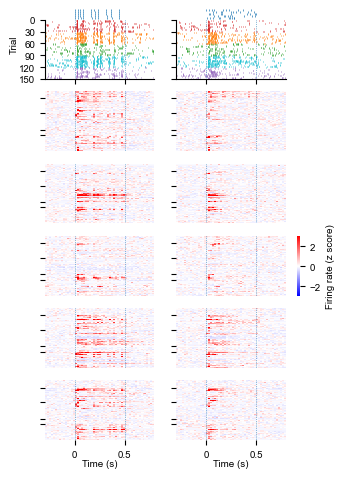

In [ ]:
# plot heatmap for all pads - TrkB hindpaw - sync vs async - order 1-5 - add stim patterns and raster example
igroup = 'TrkB_S1HP'
f, ax = plt.subplots(6,2,figsize=[3.3,4.8],gridspec_kw={'height_ratios':[7,6,6,6,6,6]})

color_palette = sns.color_palette("tab10")
colors = ["#d62728", "#ff7f0e","#2ca02c","#17becf","#9467bd"]

for i in range(10):
  units_select_zfr_pads = allunits_zfr_groups[igroup][units_select_groups[igroup],i,:]
  
  sns.heatmap(units_select_zfr_pads[units_sort_by_recordingID_depth_groups[igroup]],ax=ax[i%5+1,i//5], vmin=-3, vmax=3, cbar=False, cmap = 'bwr')

  ax[i%5+1,i//5].vlines(50, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].vlines(75, 0, len(units_select_groups[igroup]), linestyles= ':', linewidth = 0.5)
  ax[i%5+1,i//5].set_xlim(35,90)

  ax[i%5+1,i//5].set_xticks([])
  ax[i%5+1,i//5].set_xlabel('')
  ax[i%5+1,i//5].set_ylabel('')

for i in [4,9]:
  ax[i%5+1,i//5].set_xlabel('Time (s)', labelpad=0)
  ax[i%5+1,i//5].set_xticks(ticks=[50,75], labels=[0,0.5], rotation = 0)

for i in range(10):
  ax[i%5+1,i//5].set_yticks(ticks=nunits_cum_sum_recording_groups[igroup][:-1])

### plot example unit raster
iunit_dict = unit_dict_examples[igroup]
psth_laser1 = iunit_dict['psth_laser1']
trial_order_laser1 = iunit_dict['trial_order_laser1']
spk_time_laser1 = iunit_dict['spk_time_laser1']

y1 = 0
y2 = 0
yplot = -27 # sync traces
yplot0 = yplot
for icond in range(5): # plot sync 0-4
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
      
        ax[0,0].vlines(itrial_spktime-1, ymin=y1, ymax=y1+3,linewidth=0.5,color=colors[icond])
        y1 += 1
for icond in range(5,10): # plot async 05-9
    trials_icond = np.where(trial_order_laser1 == icond)[0]
    for itrial in trials_icond:
        itrial_spktime = spk_time_laser1[itrial]
        ax[0,1].vlines(itrial_spktime-1, ymin=y2, ymax=y2+3,linewidth=0.5,color=colors[icond-5])
        y2 += 1

### plot laser traces on top

for itrace in range(5): # 5 traces
    itrace_laser_time_sync  = laser_samp_sync[itrace,:] / fs_laser
    itrace_laser_time_async = laser_samp_async[itrace,:] / fs_laser
    ax[0,0].vlines(itrace_laser_time_sync,  ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    ax[0,1].vlines(itrace_laser_time_async, ymin=yplot,ymax=yplot+5,color='#1f77b4', linewidth=0.5)
    yplot += 5

ntrials = 150
for i in [0,1]:
    ax[0,i].vlines(0, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].vlines(0.5, 0, ntrials, linestyles= ':', linewidth = 0.5)
    ax[0,i].set_xlim(-0.3,0.8)
    ax[0,i].set_ylim(yplot0,150)
    ax[0,i].spines['top'].set_visible(False)
    ax[0,i].spines['right'].set_visible(False)
    ax[0,i].spines['bottom'].set_zorder(0)
    ax[0,i].spines['left'].set_bounds((0, 150))
    ax[0,i].set_xticks([0,0.5])
    ax[0,i].set_xticklabels([])
    ax[0,i].set_yticks([0,30,60,90,120,150])
    ax[0,i].invert_yaxis()

ax[0,0].set_yticklabels([0,30,60,90,120,150])
ax[0,1].set_yticklabels([])
ax[0,0].set_ylabel('Trial', labelpad=0)

norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([]) # an empty array is sufficient

cbar_ax = f.add_axes([0.9, 0.38, 0.01, 0.125]) # [left, bottom, width, height]
cbar = f.colorbar(sm, cbar_ax, label='Firing rate (z score)')
cbar.outline.set_visible(False)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.subplots_adjust(hspace=0.2, wspace=0.2) 
# plt.savefig(r"N:\Liu_Wanyi\TrkC_figures2\heatmap_raster_TrkB_S1HP_5pads_zeta_order15.pdf",dpi=600,bbox_inches='tight',transparent=True)

plt.show()